# AMD Screening Case Study 

This standalone notebook computes and plots the AMD distance matrix across all 71 CIF files
from the Materials Project (MP), Crystallography Open Database (COD), and OQMD.

The original case-study notebook is left unchanged. Results from this version are written to
the `results_v2` directory.

In [9]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

workspace_root = Path.cwd().resolve()
while workspace_root != workspace_root.parent:
    if (workspace_root / 'Features').is_dir() and (workspace_root / 'Information_Units').is_dir():
        break
    workspace_root = workspace_root.parent

if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from Features.Materials_Exploration.CifSimilarity.CifSimilarityFeature import CifSimilarityFeature

CIF_ROOT = workspace_root / 'tests' / 'fixtures' / 'cif_files'
RESULTS_DIR = workspace_root / 'Features' / 'Materials_Exploration' / 'CifSimilarity' / 'Analysis' / 'results'

print(f'Workspace root : {workspace_root}')
print(f'MP CIF files   : {len(list((CIF_ROOT / "mp").glob("*.cif")))}')
print(f'COD CIF files  : {len(list((CIF_ROOT / "cod").glob("*.cif")))}')
print(f'OQMD CIF files : {len(list((CIF_ROOT / "oqmd").glob("*.cif")))}')

Workspace root : /home/soe/EMOS
MP CIF files   : 12
COD CIF files  : 20
OQMD CIF files : 39


## Load structures and compute AMD distances

In [10]:
def load_entries(source):
    directory = CIF_ROOT / source
    return [(f'{source.upper()}/{path.stem}', path)
            for path in sorted(directory.glob('*.cif'), key=lambda p: p.stem)]


all_entries = load_entries('mp') + load_entries('cod') + load_entries('oqmd')
all_labels = [label for label, _ in all_entries]
all_paths = [path for _, path in all_entries]
all_cif_strings = [path.read_text(encoding='utf-8') for path in all_paths]

K = 15
DISTANCE_METRIC = 'amd'
cif_similarity = CifSimilarityFeature()
result = cif_similarity.process_feature({
    'cif_strings': all_cif_strings,
    'labels': all_labels,
    'distanceMetric': DISTANCE_METRIC,
    'k': K,
})

assert result['status'] == 'completed'
valid_labels = result['labels']
distance_matrix = np.asarray(result['distance_matrix'], dtype=float)
invalid_labels = [label for label in all_labels if label not in valid_labels]

assert distance_matrix.shape == (len(valid_labels), len(valid_labels))
assert np.allclose(distance_matrix, distance_matrix.T)
assert np.allclose(np.diag(distance_matrix), 0.0)

print(f'Total CIF files       : {len(all_labels)}')
print(f'Valid CIF files       : {len(valid_labels)}')
print(f'Invalid CIF files     : {len(invalid_labels)}')
if invalid_labels:
    print(f'Invalid labels        : {invalid_labels}')
print(f'Distance matrix shape : {distance_matrix.shape}')
print(f'Unique pairs compared : {len(valid_labels) * (len(valid_labels) - 1) // 2}')

Total CIF files       : 71
Valid CIF files       : 70
Invalid CIF files     : 1
Invalid labels        : ['COD/cod-3000626']
Distance matrix shape : (70, 70)
Unique pairs compared : 2415


In [11]:
distance_df = pd.DataFrame(distance_matrix, index=valid_labels, columns=valid_labels)
display(distance_df)

RESULTS_DIR.mkdir(exist_ok=True)
csv_path = RESULTS_DIR / 'all_cif_distance_matrix.csv'
distance_df.to_csv(csv_path)
print(f'Matrix CSV saved to : {csv_path}')

,MP/mp-1017539,MP/mp-1093993,MP/mp-1245015,MP/mp-1245109,MP/mp-1245209,MP/mp-1245255,MP/mp-13161,MP/mp-1986,MP/mp-2133,MP/mp-2229,...,OQMD/oqmd-2029843,OQMD/oqmd-2029844,OQMD/oqmd-20684,OQMD/oqmd-20685,OQMD/oqmd-2170474,OQMD/oqmd-307732,OQMD/oqmd-328816,OQMD/oqmd-339274,OQMD/oqmd-4908,OQMD/oqmd-6958
MP/mp-1017539,0.000000,0.775187,0.498049,0.449518,0.539221,0.487000,0.679753,0.813697,0.807768,0.647277,...,0.798834,0.796623,0.707003,0.805501,0.794846,0.701945,0.671546,0.704633,0.793331,0.670811
MP/mp-1093993,0.775187,0.000000,0.355709,0.325669,0.366746,0.338691,0.958604,0.377391,0.365105,1.089337,...,0.382134,0.393637,0.985854,0.390777,0.392530,0.980796,1.113606,0.983484,0.372439,1.112871
MP/mp-1245015,0.498049,0.355709,0.000000,0.087960,0.042080,0.026248,0.881639,0.422175,0.408178,0.798669,...,0.407800,0.419303,0.913105,0.416443,0.418196,0.907264,0.822939,0.910367,0.398105,0.822203
MP/mp-1245109,0.449518,0.325669,0.087960,0.000000,0.098997,0.070941,0.815989,0.385709,0.373424,0.779294,...,0.390453,0.401956,0.847455,0.399096,0.400849,0.841614,0.803564,0.844717,0.380758,0.802828
MP/mp-1245209,0.539221,0.366746,0.042080,0.098997,0.000000,0.052221,0.889923,0.433212,0.420118,0.756589,...,0.437147,0.448649,0.921389,0.445789,0.447542,0.915548,0.780859,0.918652,0.427452,0.780123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OQMD/oqmd-307732,0.701945,0.980796,0.907264,0.841614,0.915548,0.890085,0.036239,0.914329,0.902044,0.759031,...,0.922083,0.933584,0.008260,0.927715,0.932278,0.000000,0.736888,0.004389,0.909378,0.735848
OQMD/oqmd-328816,0.671546,1.113606,0.822939,0.803564,0.780859,0.804132,0.773127,1.078180,1.065895,0.034322,...,1.082924,1.094427,0.729767,1.091566,1.093319,0.736888,0.000000,0.732499,1.073229,0.001040
OQMD/oqmd-339274,0.704633,0.983484,0.910367,0.844717,0.918652,0.893188,0.040628,0.917017,0.904731,0.761718,...,0.924771,0.936271,0.003872,0.930403,0.934965,0.004389,0.732499,0.000000,0.912065,0.731459
OQMD/oqmd-4908,0.793331,0.372439,0.398105,0.380758,0.427452,0.424353,0.887186,0.036587,0.022590,1.048959,...,0.027638,0.024206,0.914436,0.023202,0.028843,0.909378,1.073229,0.912065,0.000000,1.072493


Matrix CSV saved to : /home/soe/EMOS/Features/Materials_Exploration/CifSimilarity/Analysis/results/all_cif_distance_matrix.csv


## Plot the CIF similarity distance matrix

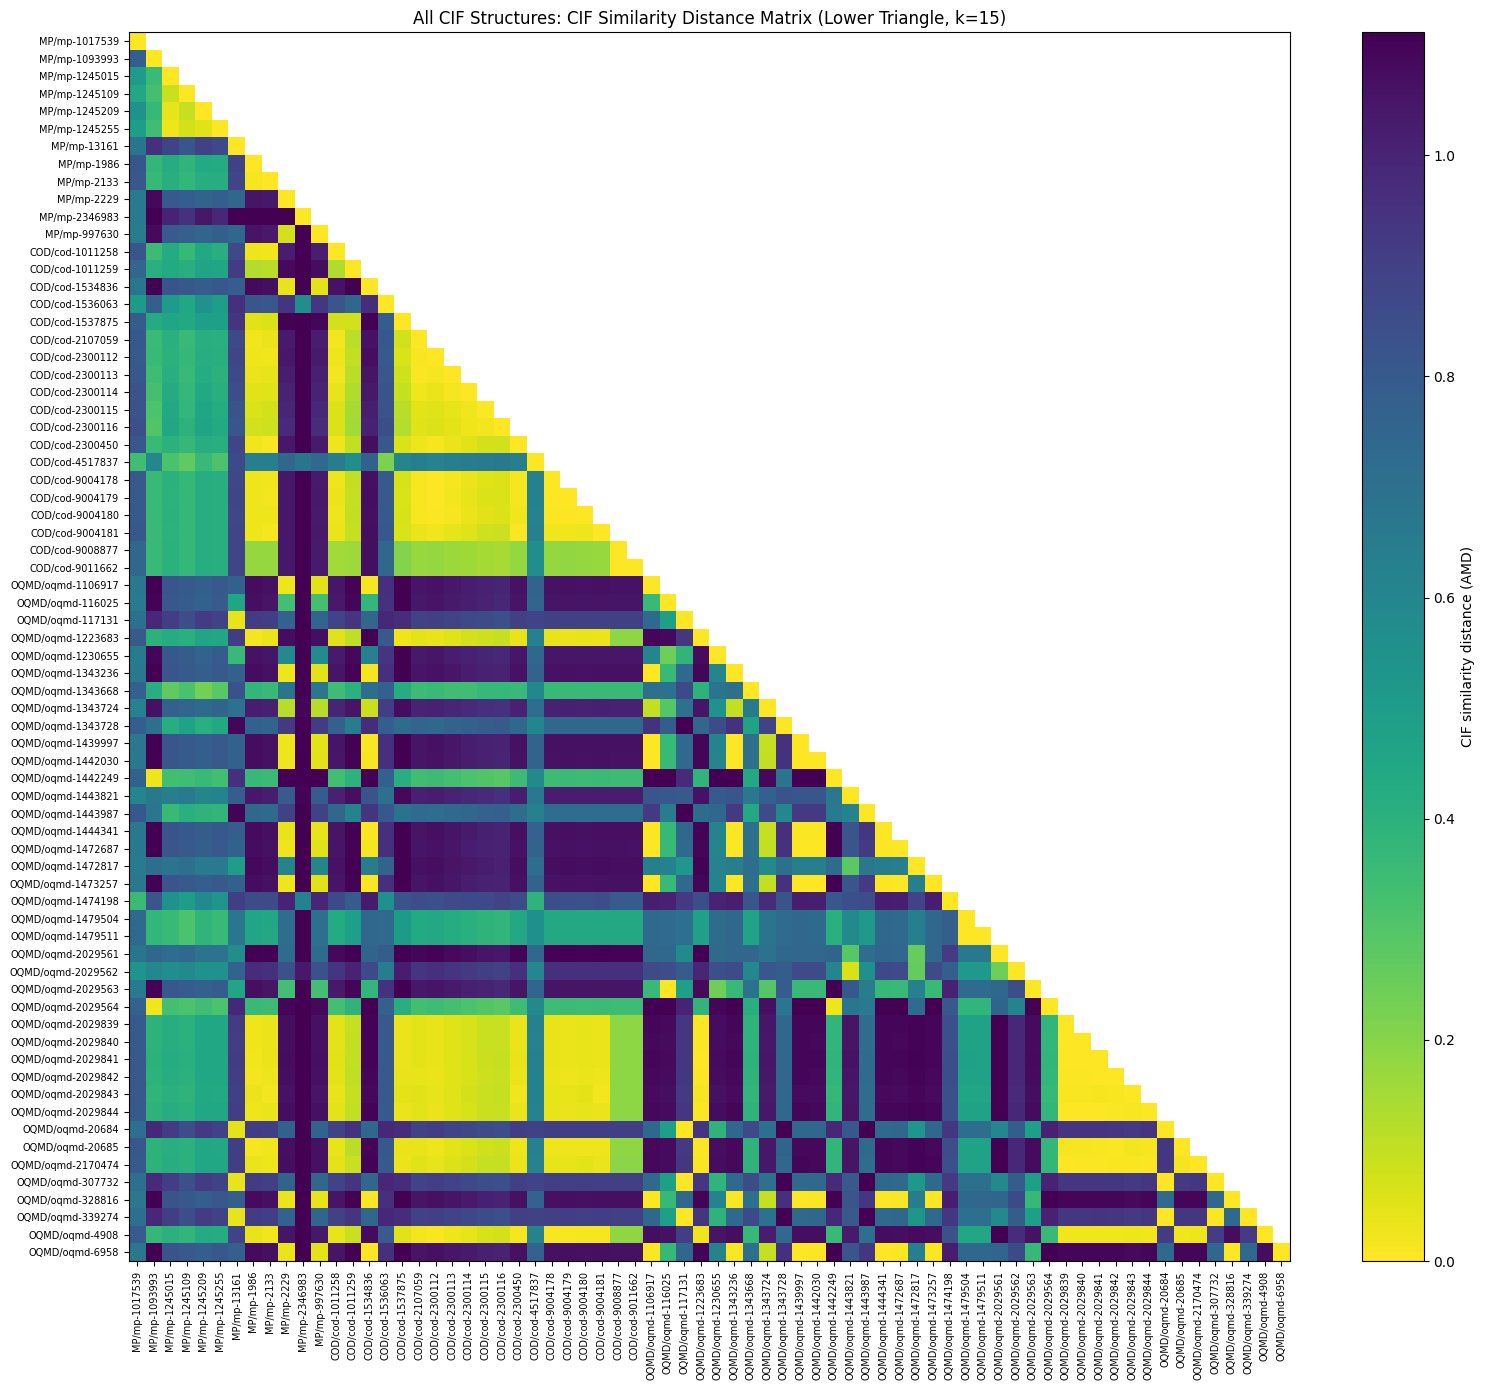

Heatmap saved to    : /home/soe/EMOS/Features/Materials_Exploration/CifSimilarity/Analysis/results/all_cif_distance_matrix_lower_triangle.png


In [12]:
# Keep only the lower triangle (including diagonal) and mask the upper triangle.
upper_triangle_mask = np.triu(np.ones_like(distance_matrix, dtype=bool), k=1)
distance_lower_triangle = np.ma.array(distance_matrix, mask=upper_triangle_mask)

finite_distances = distance_lower_triangle.compressed()
finite_distances = finite_distances[np.isfinite(finite_distances) & (finite_distances > 0)]
vmax = float(np.percentile(finite_distances, 95)) if finite_distances.size else 1.0

cmap = plt.cm.viridis_r.copy()
cmap.set_bad(color='white', alpha=0.0)

fig, ax = plt.subplots(figsize=(16, 14))
image = ax.imshow(distance_lower_triangle, cmap=cmap, aspect='auto', vmin=0, vmax=vmax)
fig.colorbar(image, ax=ax, label=f'CIF similarity distance ({DISTANCE_METRIC.upper()})')
ax.set_xticks(range(len(valid_labels)))
ax.set_yticks(range(len(valid_labels)))
ax.set_xticklabels(valid_labels, rotation=90, fontsize=7)
ax.set_yticklabels(valid_labels, fontsize=7)
ax.set_title('All CIF Structures: CIF Similarity Distance Matrix (Lower Triangle, k=15)')
plt.tight_layout()

plot_path = RESULTS_DIR / 'all_cif_distance_matrix_lower_triangle.png'
fig.savefig(plot_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Heatmap saved to    : {plot_path}')